In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import pandas as pd
import os

In [2]:
def strTmpt(t):
    if t == 1:
        return 't001'
    elif t < 100:
        return 't0'+str(t)
    else:
        return 't'+str(t)

def findFile(netType, t,randCat):
    fol = os.listdir('DIFF_TmptDiffs/'+randCat)
    fileName = netType+'_Trained_on_'+strTmpt(t)
    fileOI = ''
    count = 0
    for i in fol:
        if fileName in i:
            fileOI = i
            count = count+1
    if count > 1:
        print('Something went wrong: more than file for this timepoint')
    elif count < 1:
        print('Something went wrong: no file for this timepoint')
    return fileOI
              
#netType = 'TDANet'
netType = 'ResNet'

noLastTimepoint = False
randCat = 'RandCat1'

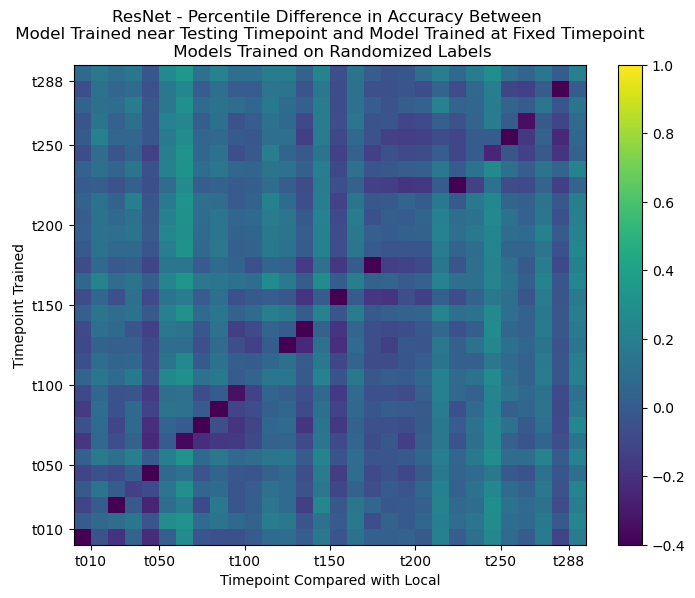

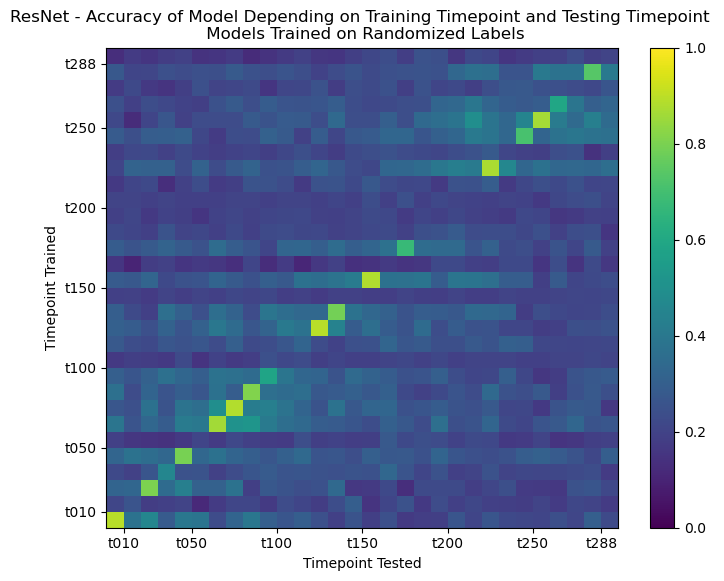

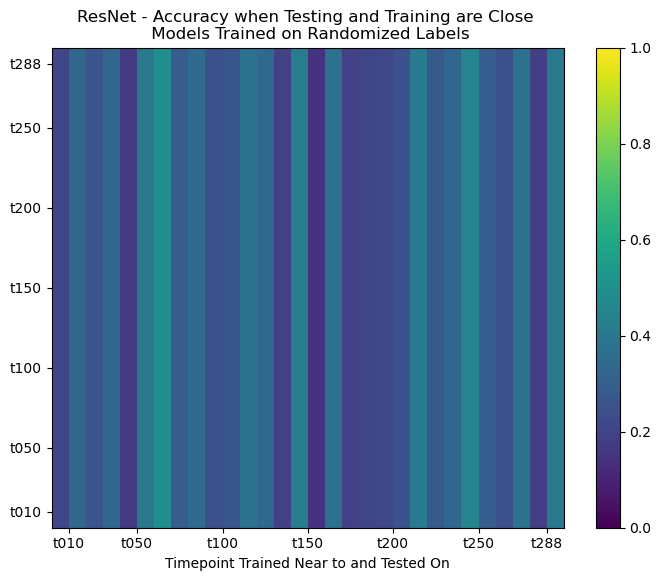

In [3]:
viridis = mpl.colormaps['viridis']
tmpt_differentials = []
fixed_accuracy = []
float_accuracy = []
#something is going on with the very last timepoint;
#there is a tremendous jump in performance between t288 and the earlier timepoints when trained on
#one and tested on the other (see TDA_Trained_on_t287/t288 graphs in Fi_Accuacy)
#tried t287 instead, since I thought it might be that the last timepoint is when we've done
#fixing and staining, but t287 has the same problem
#will cut it out for now
if noLastTimepoint:
    #change for loop so that we don't include top row, the row where we tested 
    #the 'trained on t288' model on earlier timepoints
    tmpts = [1]+list(range(10,290,10))
else:
    tmpts = [1]+list(range(10,290,10))+[288]

for t in tmpts: 
    df = pd.read_csv('DIFF_TmptDiffs/'+randCat+'/'+findFile(netType,t,randCat))
    if noLastTimepoint:
        #change indexing so we don't include last column, the column where we tested on't288'
        #the models trained on earlier timepoints 
        fixed_accuracy.append(list(df['Fixed Accuracy'][:-1]))
        tmpt_differentials.append(list(df['Diff. Accuracy'][:-1]))
        float_accuracy.append(list(df['Floating Accuracy'][:-1]))
    else:
        fixed_accuracy.append(list(df['Fixed Accuracy']))
        tmpt_differentials.append(list(df['Diff. Accuracy']))
        float_accuracy.append(list(df['Floating Accuracy']))        

tmpt_diffs = np.array(tmpt_differentials)
figm = plt.figure()
axm = figm.add_axes([0,0,1,1])
psm = axm.pcolormesh(tmpt_diffs, cmap=viridis, rasterized=True, vmin = -0.4, vmax = 1)
#psm = axm.pcolormesh(tmpt_diffs, cmap=viridis, rasterized=True)
figm.colorbar(psm, ax=axm)
#This is what the xticks looked like originally (when I called plt.xticks()
#(array([ 0.,  5., 10., 15., 20., 25., 30.]), [Text(0.0, 0, '0'), Text(5.0, 0, '5'), \
#                                              Text(10.0, 0, '10'), Text(15.0, 0, '15'),\
#                                              Text(20.0, 0, '20'), Text(25.0, 0, '25'),\
#                                              Text(30.0, 0, '30')])
plt.xticks([1.,  5., 10., 15., 20., 25.,29.], ['t010', 't050', \
                                              't100', 't150',\
                                              't200','t250','t288'])
plt.yticks([1.,  5., 10., 15., 20., 25.,29.], ['t010', 't050', \
                                              't100', 't150',\
                                              't200','t250','t288'])
axm.set_xlabel('Timepoint Compared with Local')
axm.set_ylabel('Timepoint Trained')
if randCat == 'Actual':
    axm.set_title(netType + ' - Percentile Difference in Accuracy Between \n Model Trained near Testing Timepoint and Model Trained at Fixed Timepoint \n Models Trained on Actual Labels')
else:
    axm.set_title(netType + ' - Percentile Difference in Accuracy Between \n Model Trained near Testing Timepoint and Model Trained at Fixed Timepoint \n Models Trained on Randomized Labels')    
figm.savefig('DIFF_TmptDiffs/'+netType+'_'+randCat+'_DifferentialAccuracy.jpg',bbox_inches='tight')
plt.show()

#fixed_accuracy = []
#for t in [1]+list(range(10,290,10))+[288]: 
    #df = pd.read_csv('Timepoint_Differentials/Metrics/'+findFile(netType,t))
#    df = pd.read_csv('Timepoint_Differentials/From_Pace/Metrics/'+findFile(netType,t))
#    fixed_accuracy.append(list(df['Fixed Accuracy']))
fixed_acc = np.array(fixed_accuracy)
figfix = plt.figure()
axfix = figfix.add_axes([0,0,1,1])
#psfix = axfix.pcolormesh(fixed_acc, cmap=viridis, rasterized=True, vmin = 0, vmax = 1)
psfix = axfix.pcolormesh(fixed_acc, cmap=viridis, rasterized=True, vmin = 0, vmax = 1)
figfix.colorbar(psfix, ax=axfix)
plt.xticks([1.,  5., 10., 15., 20., 25.,29.], ['t010', 't050', \
                                              't100', 't150',\
                                              't200','t250','t288'])
plt.yticks([1.,  5., 10., 15., 20., 25.,29.], ['t010', 't050', \
                                              't100', 't150',\
                                              't200','t250','t288'])
axfix.set_xlabel('Timepoint Tested')
axfix.set_ylabel('Timepoint Trained')
if randCat == 'Actual':
    axfix.set_title(netType + ' - Accuracy of Model Depending on Training Timepoint and Testing Timepoint \n Models Trained on Actual Labels')
else:
    axfix.set_title(netType + ' - Accuracy of Model Depending on Training Timepoint and Testing Timepoint \n Models Trained on Randomized Labels')
figfix.savefig('DIFF_TmptDiffs/'+netType+'_'+randCat+'_FixedAccuracy.jpg',bbox_inches='tight')

plt.show()

#float_accuracy = []
#for t in [1]+list(range(10,290,10))+[288]: 
#    #df = pd.read_csv('Timepoint_Differentials/Metrics/'+findFile(netType,t))
#    df = pd.read_csv('Timepoint_Differentials/From_Pace/Metrics/'+findFile(netType,t))
#    float_accuracy.append(list(df['Floating Accuracy']))
float_acc = np.array(float_accuracy)
figflo = plt.figure()
axflo = figflo.add_axes([0,0,1,1])
psflo = axflo.pcolormesh(float_acc, cmap=viridis, rasterized=True, vmin = 0, vmax = 1)
#psflo = axflo.pcolormesh(float_acc, cmap=viridis, rasterized=True)
figflo.colorbar(psflo, ax=axflo)
plt.xticks([1.,  5., 10., 15., 20., 25.,29.], ['t010', 't050', \
                                              't100', 't150',\
                                              't200','t250','t288'])
plt.yticks([1.,  5., 10., 15., 20., 25.,29.], ['t010', 't050', \
                                              't100', 't150',\
                                              't200','t250','t288'])
#axflo.set_xlabel('')
axflo.set_xlabel('Timepoint Trained Near to and Tested On')
if randCat == 'Actual':
    axflo.set_title(netType+' - Accuracy when Testing and Training are Close \n Models Trained on Actual Labels')
else:
    axflo.set_title(netType+' - Accuracy when Testing and Training are Close \n Models Trained on Randomized Labels')
figflo.savefig('DIFF_TmptDiffs/'+netType+'_'+randCat+'_FloatingAccuracy.jpg',bbox_inches='tight')
plt.show()

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

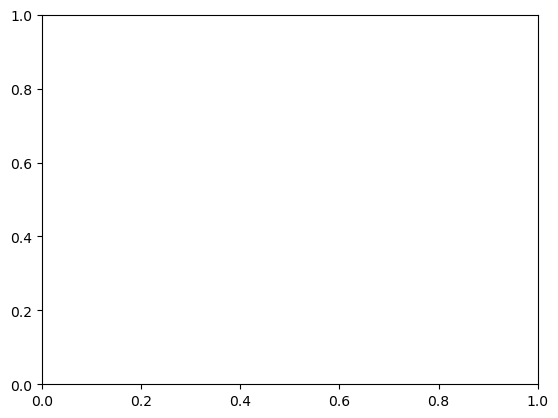

In [20]:
plt.xticks()